# Image Denoising using a U-Net Autoencoder on MNIST

This notebook demonstrates how to construct and train a deep convolutional autoencoder to reconstruct clean images from noisy inputs. We will be using the MNIST dataset of handwritten digits and applying a U-Net style architecture with skip connections to preserve high-frequency spatial details.

### 1. Environment Setup & Imports
First, we import the necessary mathematical, visualization, and deep learning libraries. We also establish a global random seed. Setting a fixed seed (`42`) is a critical practice to ensure that our noise injection and model weight initializations remain deterministic and reproducible across multiple execution runs.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Ensure reproducibility across runs
tf.keras.utils.set_random_seed(42)
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


### 2. Data Preprocessing & Noise Injection
Here, we prepare the MNIST dataset for our convolutional network. We normalize the pixel intensities to a `[0, 1]` range and expand the dimensions to include a single color channel (28x28x1). To train the model to denoise, we artificially corrupt our training and testing sets by injecting Gaussian noise. We use `np.clip` to ensure the corrupted pixel values do not exceed the valid 0 to 1 range.

In [11]:
print("Loading and preparing MNIST data...")
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and expand dimensions
x_train = np.expand_dims(x_train.astype('float32') / 255., -1)
x_test = np.expand_dims(x_test.astype('float32') / 255., -1)

# Inject Gaussian Noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to ensure they stay within the valid pixel intensity range [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print(f"Training data shape: {x_train_noisy.shape}")
print(f"Testing data shape: {x_test_noisy.shape}")

Loading and preparing MNIST data...
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


### 3. Autoencoder Architecture Construction
This cell defines the core Convolutional Denoising Autoencoder (CDAE). 
* **Encoder:** Progressively downsamples the spatial dimensions using `MaxPooling2D` while increasing the feature depth, ultimately compressing the image into a dense latent representation (the bottleneck). `BatchNormalization` is included to stabilize and accelerate training.
* **Decoder:** Reverses the compression using `UpSampling2D` to restore the image back to its original 28x28 resolution. The final convolutional layer uses a `sigmoid` activation to map the output directly to valid pixel intensities.

In [12]:
inputs = layers.Input(shape=(28, 28, 1))

# --- Encoder ---
conv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
pool1 = layers.MaxPooling2D((2, 2), padding='same')(conv1) # Down to 14x14

conv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
pool2 = layers.MaxPooling2D((2, 2), padding='same')(conv2) # Down to 7x7

# --- Bottleneck ---
conv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)

# --- Decoder with Skip Connections ---
up1 = layers.UpSampling2D((2, 2))(conv3) # Up to 14x14
merge1 = layers.concatenate([up1, conv2]) # Skip connection from conv2
conv4 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(merge1)

up2 = layers.UpSampling2D((2, 2))(conv4) # Up to 28x28
merge2 = layers.concatenate([up2, conv1]) # Skip connection from conv1
conv5 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(merge2)

outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(conv5)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 64)  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │     27,680 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28, 1) │        289 │ conv2d_6[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 231,297 (903.50 KB)

 Trainable params: 231,297 (903.50 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Model Compilation & Training
We compile the model using the `adam` optimizer and `binary_crossentropy` loss, which calculates the pixel-by-pixel reconstruction error. The network learns by taking the `x_train_noisy` images as input and attempting to map them to the clean `x_train` targets. We capture the `history` object during `.fit()` to visualize our training and validation loss curves, allowing us to monitor for convergence and prevent overfitting.

In [13]:
EPOCHS = 50
BATCH_SIZE = 128

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=5,          # Stop if no improvement for 5 epochs
    restore_best_weights=True, # Automatically load the best model when training stops
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='unet_best_weights.weights.h5', 
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

print("Starting training...")
# Keras handles the progress bar naturally (verbose=1)
history = model.fit(
    x=x_train_noisy, 
    y=x_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)
print("Training complete. Best weights are loaded and saved.")

Starting training...
Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1868
Epoch 1: val_loss improved from None to 0.10035, saving model to unet_best_weights.weights.h5

Epoch 1: finished saving model to unet_best_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.1262 - val_loss: 0.1003
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1000
Epoch 2: val_loss improved from 0.10035 to 0.09567, saving model to unet_best_weights.weights.h5

Epoch 2: finished saving model to unet_best_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0987 - val_loss: 0.0957
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0962
Epoch 3: val_loss improved from 0.09567 to 0.09393, saving model to unet_best_weights.weights.h5

Epoch 3: finished saving model to unet_best_weights.weights.h5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0957 - val_loss: 0.0939
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.094

### 5. Visualizing Qualitative Performance
To evaluate how well our model generalizes, we pass a batch of unseen, noisy test images through the trained autoencoder. Using Matplotlib, we plot a visual comparison of the Original clean target, the Noisy input, and the Denoised reconstruction to visually inspect the network's ability to filter statistical noise while retaining the structural geometry of the digits.

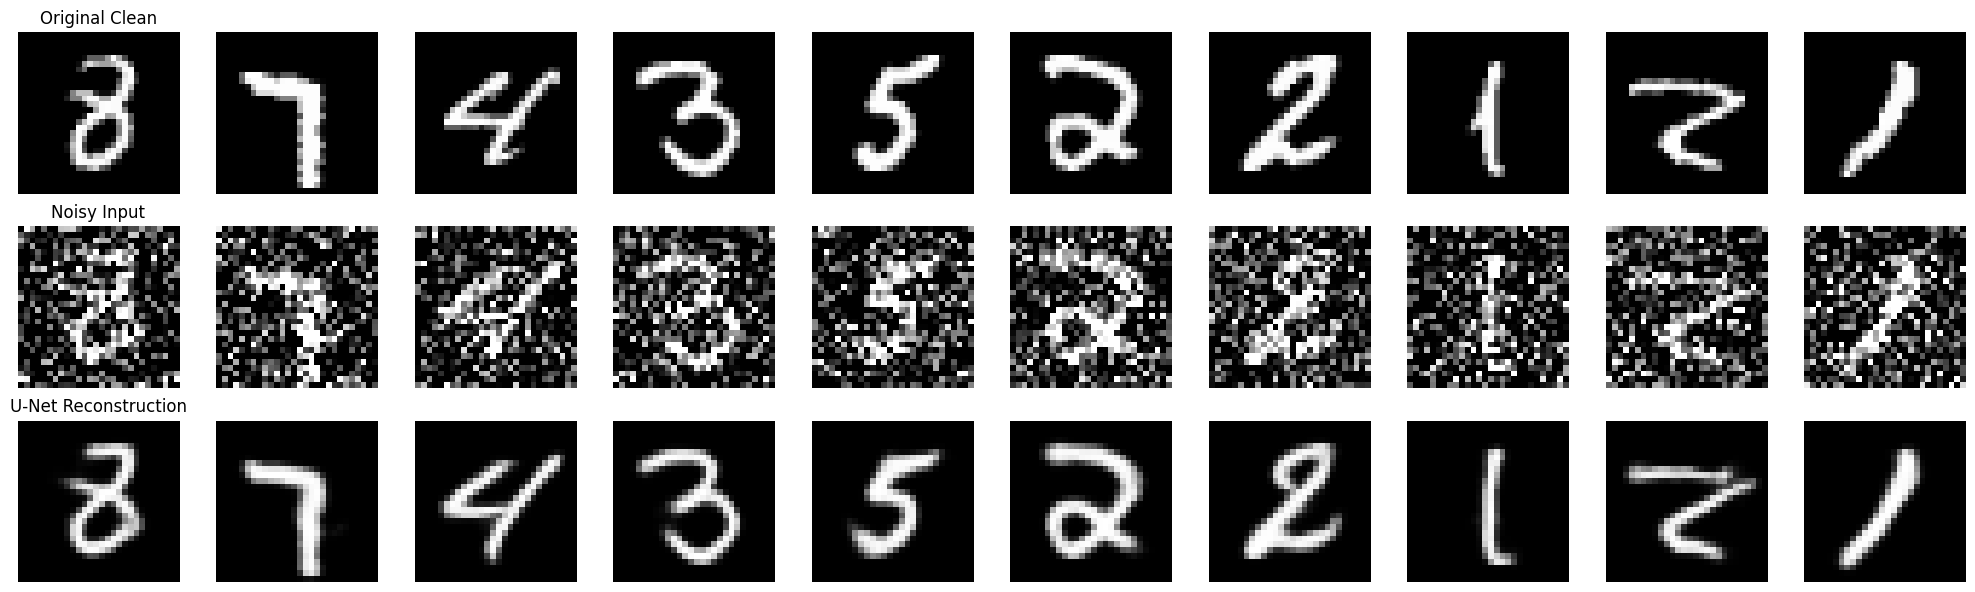

In [16]:
# Select a few random test images
num_images = 10
random_indices = np.random.choice(x_test.shape[0], num_images, replace=False)

noisy_samples = x_test_noisy[random_indices]
clean_samples = x_test[random_indices]

# Run inference using the trained model
reconstructed_samples = model.predict(noisy_samples, verbose=0)

# Plotting the results
fig, axes = plt.subplots(3, num_images, figsize=(20, 6))
for i in range(num_images):
    # Original
    axes[0, i].imshow(clean_samples[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original Clean")
    
    # Noisy Input
    axes[1, i].imshow(noisy_samples[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Noisy Input")
    
    # Reconstruction
    axes[2, i].imshow(reconstructed_samples[i].squeeze(), cmap='gray')
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("U-Net Reconstruction")

plt.tight_layout()
plt.show()

### 6. The Victim Classifier
To prove the effectiveness of our defense, we first need a baseline system to attack. Here, we build a standard Convolutional Neural Network (CNN) classifier. We will train it on the clean, unperturbed MNIST dataset to establish a high baseline accuracy.

In [17]:
# Load the labels (we only loaded the images in Cell 1)
(_, y_train), (_, y_test) = mnist.load_data()

# Build a simple, lightweight CNN classifier
classifier = tf.keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for digits 0-9
])

classifier.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Training the victim classifier on clean data...")
classifier.fit(x_train, y_train, epochs=3, batch_size=128, validation_data=(x_test, y_test))

# Establish baseline accuracy
clean_loss, clean_acc = classifier.evaluate(x_test, y_test, verbose=0)
print(f"\nBaseline Accuracy on Clean Test Data: {clean_acc * 100:.2f}%")

Training the victim classifier on clean data...
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9337 - loss: 0.2315 - val_accuracy: 0.9777 - val_loss: 0.0716
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9818 - loss: 0.0591 - val_accuracy: 0.9839 - val_loss: 0.0529
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9872 - loss: 0.0415 - val_accuracy: 0.9851 - val_loss: 0.0448

Baseline Accuracy on Clean Test Data: 98.51%


### 7. Fast Gradient Sign Method (FGSM)
We implement the FGSM attack to generate adversarial perturbations. This function takes an image, calculates the gradient of the classifier's loss with respect to the input pixels, and extracts the sign of that gradient. By adding this structured noise back to the image (scaled by `epsilon`), we push the image in the exact mathematical direction that maximizes the classifier's error.

In [18]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

def generate_adversarial_pattern(input_image, input_label):
    input_image = tf.convert_to_tensor(input_image)
    
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = classifier(input_image)
        loss = loss_object(input_label, prediction)

    # Get the gradients of the loss w.r.t to the input image.
    gradient = tape.gradient(loss, input_image)
    
    # Get the sign of the gradients to create the perturbation
    signed_grad = tf.sign(gradient)
    return signed_grad

print("FGSM Attack function ready.")

FGSM Attack function ready.


### 8. Evaluating the Attack Surface and U-Net Defense
We will now generate adversarial examples for the entire test set. We will evaluate the classifier's accuracy on these compromised images to demonstrate the vulnerability. Finally, we will pass the adversarial images through our trained U-Net to "purify" them, and evaluate the classifier one last time to measure the recovery of our system's integrity.

In [19]:
# Generate adversarial noise for the test set
epsilon = 0.15 # Strength of the attack
print("Generating adversarial perturbations for the test set...")

# Batch processing for memory efficiency
perturbations = []
for i in range(0, len(x_test), 1000):
    batch_images = x_test[i:i+1000]
    batch_labels = y_test[i:i+1000]
    batch_perturbation = generate_adversarial_pattern(batch_images, batch_labels)
    perturbations.append(batch_perturbation)
    
perturbations = tf.concat(perturbations, axis=0)

# Create the adversarial images
x_test_adv = x_test + epsilon * perturbations
x_test_adv = tf.clip_by_value(x_test_adv, 0, 1) # Ensure valid pixel range

# 1. Test the attack
adv_loss, adv_acc = classifier.evaluate(x_test_adv, y_test, verbose=0)
print(f"Accuracy under FGSM Attack (Epsilon={epsilon}): {adv_acc * 100:.2f}%")

# 2. Deploy the Defense (Your U-Net)
print("\nPurifying adversarial images through U-Net...")
x_test_purified = model.predict(x_test_adv, batch_size=128)

# 3. Test the recovery
rec_loss, rec_acc = classifier.evaluate(x_test_purified, y_test, verbose=0)
print(f"Accuracy after U-Net Purification: {rec_acc * 100:.2f}%")

Generating adversarial perturbations for the test set...
Accuracy under FGSM Attack (Epsilon=0.15): 57.33%

Purifying adversarial images through U-Net...
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy after U-Net Purification: 91.59%


### 9. Visualizing the Purification Pipeline
To understand the mechanics of the attack and defense, we visualize a single sample moving through the pipeline: the original image, the calculated adversarial perturbation, the corrupted input, and the final purified output from the U-Net.

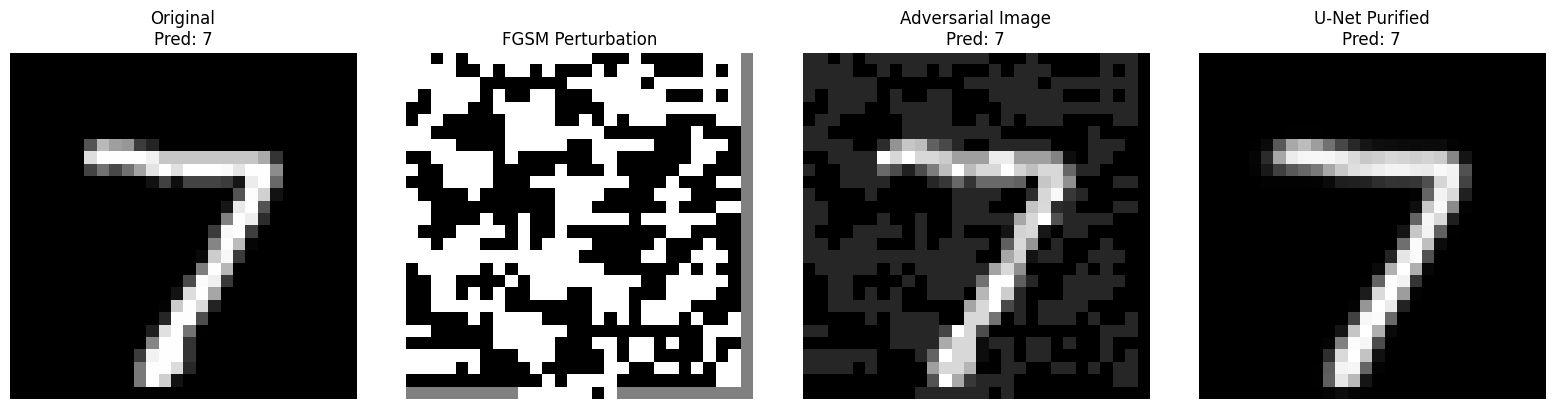

In [20]:
# Select a specific image to visualize
index = 0
image = x_test[index:index+1]
label = y_test[index:index+1]
perturbation = perturbations[index:index+1]
adv_image = x_test_adv[index:index+1]
purified_image = x_test_purified[index:index+1]

# Get classifier predictions to show how the attack worked
pred_clean = np.argmax(classifier.predict(image, verbose=0))
pred_adv = np.argmax(classifier.predict(adv_image, verbose=0))
pred_purified = np.argmax(classifier.predict(purified_image, verbose=0))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image.squeeze(), cmap='gray')
axes[0].set_title(f"Original\nPred: {pred_clean}")
axes[0].axis('off')

# Displaying the noise, scaled for visibility
axes[1].imshow(perturbation.numpy().squeeze() * 0.5 + 0.5, cmap='gray')
axes[1].set_title("FGSM Perturbation")
axes[1].axis('off')

axes[2].imshow(adv_image.numpy().squeeze(), cmap='gray')
axes[2].set_title(f"Adversarial Image\nPred: {pred_adv}")
axes[2].axis('off')

axes[3].imshow(purified_image.squeeze(), cmap='gray')
axes[3].set_title(f"U-Net Purified\nPred: {pred_purified}")
axes[3].axis('off')

plt.tight_layout()
plt.show()